# Taller Transformaciones Homogéneas

## 0. Instalación Automática de Dependencias

In [1]:
import subprocess
import sys

# Instalar dependencias automáticamente
libraries = ['numpy', 'matplotlib', 'scipy', 'plotly', 'ipywidgets', 'anywidget']

for lib in libraries:
    try:
        __import__(lib)
        print(f"✓ {lib} ya está instalado")
    except ImportError:
        print(f"Installing {lib}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", lib, "-q"])
        print(f"✓ {lib} instalado correctamente")

print("\n✅ Todas las dependencias están listas!")

✓ numpy ya está instalado
✓ matplotlib ya está instalado
✓ scipy ya está instalado
✓ plotly ya está instalado
✓ ipywidgets ya está instalado
✓ anywidget ya está instalado

✅ Todas las dependencias están listas!


## Importar Librerías Necesarias

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 1. Coordenadas homogéneas en 2D
- Representar puntos 2D en coordenadas homogéneas (x, y, 1)
- Crear matrices de transformation 3x3 (Traslación, Rotación, Escalamiento, Reflexión)
- Aplicar transformaciones a conjunto de puntos
- Visualizar resultado con matplotlib

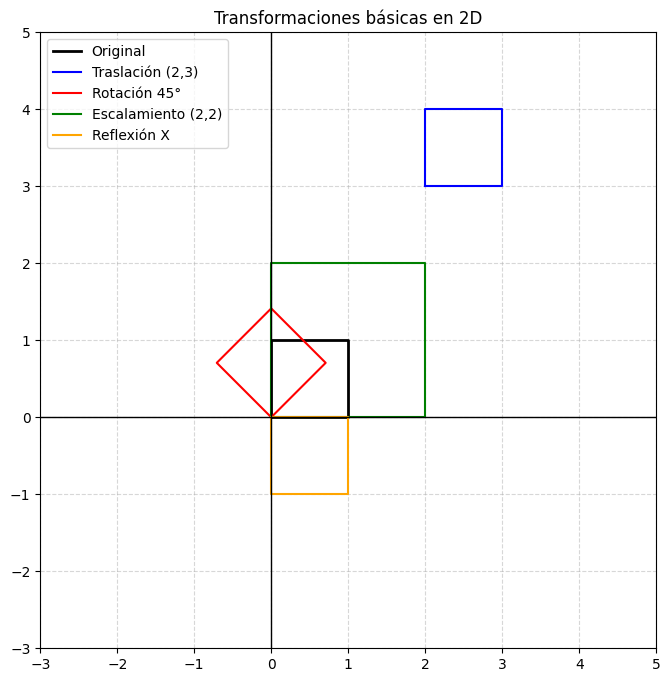

In [3]:
def translation_2d(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

def rotation_2d(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,             0,            1]
    ])

def scaling_2d(sx, sy):
    return np.array([
        [sx, 0,  0],
        [0,  sy, 0],
        [0,  0,  1]
    ])

def reflection_2d(axis='x'):
    if axis == 'x':
        return np.array([
            [1,  0, 0],
            [0, -1, 0],
            [0,  0, 1]
        ])
    elif axis == 'y':
        return np.array([
            [-1, 0, 0],
            [ 0, 1, 0],
            [ 0, 0, 1]
        ])
    return np.eye(3)

def apply_transformation(points, matrix):
    # points: Nx2 array
    n = points.shape[0]
    homogenous_points = np.hstack([points, np.ones((n, 1))])
    transformed = (matrix @ homogenous_points.T).T
    return transformed[:, :2]

# Conjunto de puntos: un pequeño cuadrado
square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
    [0, 0]
])

# Aplicar transformaciones
T = translation_2d(2, 3)
R = rotation_2d(45)
S = scaling_2d(2, 2)
Ref = reflection_2d('x')

poly_T = apply_transformation(square, T)
poly_R = apply_transformation(square, R)
poly_S = apply_transformation(square, S)
poly_Ref = apply_transformation(square, Ref)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(square[:,0], square[:,1], label='Original', color='black', linewidth=2)
ax.plot(poly_T[:,0], poly_T[:,1], label='Traslación (2,3)', color='blue')
ax.plot(poly_R[:,0], poly_R[:,1], label='Rotación 45°', color='red')
ax.plot(poly_S[:,0], poly_S[:,1], label='Escalamiento (2,2)', color='green')
ax.plot(poly_Ref[:,0], poly_Ref[:,1], label='Reflexión X', color='orange')

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(-3, 5)
ax.set_ylim(-3, 5)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.legend()
plt.title("Transformaciones básicas en 2D")
plt.show()


## 2. Composición de transformaciones
- Crear secuencia de transformaciones
- Multiplicar matrices en orden correcto
- Demostrar que el orden importa (no conmutativo)
- Aplicar transformación compuesta
- Comparar con aplicar transformaciones secuencialmente

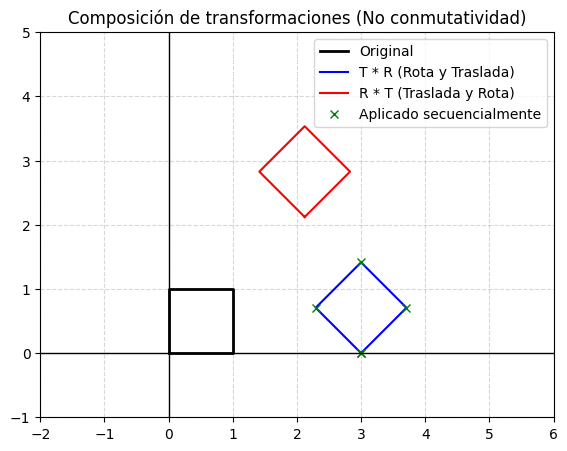

Matriz M1 (T * R):
 [[ 0.70710678 -0.70710678  3.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]

Matriz M2 (R * T):
 [[ 0.70710678 -0.70710678  2.12132034]
 [ 0.70710678  0.70710678  2.12132034]
 [ 0.          0.          1.        ]]

M1 != M2, por lo tanto no es conmutativo.


In [4]:
# Secuencia: Rotación de 45° y traslación de (3, 0)
R = rotation_2d(45)
T = translation_2d(3, 0)

# M1 = T * R (Primero R, luego T - El vector esta a la derecha: T * R * v)
M1 = T @ R
poly_M1 = apply_transformation(square, M1)

# M2 = R * T (Primero T, luego R)
M2 = R @ T
poly_M2 = apply_transformation(square, M2)

# Demostración
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(square[:,0], square[:,1], label='Original', color='black', linewidth=2)
ax.plot(poly_M1[:,0], poly_M1[:,1], label='T * R (Rota y Traslada)', color='blue')
ax.plot(poly_M2[:,0], poly_M2[:,1], label='R * T (Traslada y Rota)', color='red')

# Secuencial (T * R) equivalente a (T * (R * v))
poly_seq1 = apply_transformation(square, R) 
poly_seq_final = apply_transformation(poly_seq1, T)

ax.plot(poly_seq_final[:,0], poly_seq_final[:,1], 'x', label='Aplicado secuencialmente', color='green')

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(-2, 6)
ax.set_ylim(-1, 5)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.legend()
plt.title("Composición de transformaciones (No conmutatividad)")
plt.show()

print("Matriz M1 (T * R):\n", M1)
print("\nMatriz M2 (R * T):\n", M2)
print("\nM1 != M2, por lo tanto no es conmutativo.")


## 3. Coordenadas homogéneas en 3D
- Representar puntos 3D (x, y, z, 1)
- Matrices 4x4 para transformaciones 3D
- Implementar todas las transformaciones básicas
- Visualizar cubo transformado en 3D

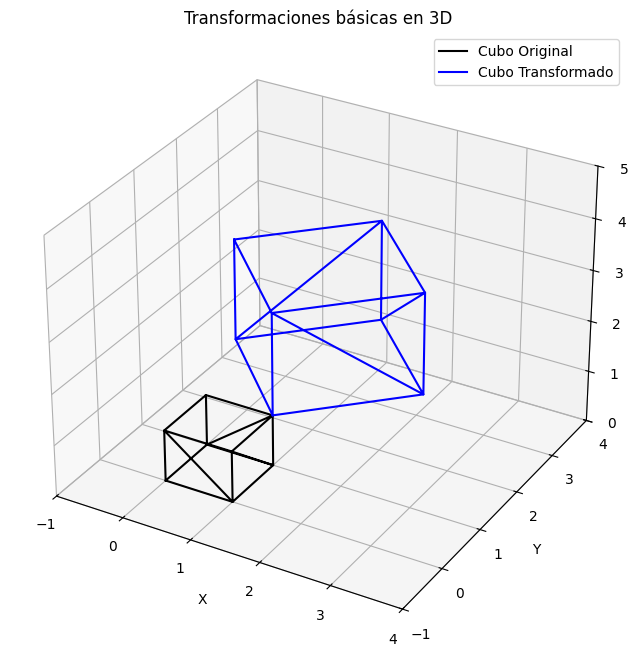

In [5]:
def translation_3d(tx, ty, tz):
    return np.array([
        [1, 0, 0, tx],
        [0, 1, 0, ty],
        [0, 0, 1, tz],
        [0, 0, 0, 1]
    ])

def rotation_3d_x(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta), -np.sin(theta), 0],
        [0, np.sin(theta),  np.cos(theta), 0],
        [0, 0, 0, 1]
    ])

def rotation_3d_y(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([
        [ np.cos(theta), 0, np.sin(theta), 0],
        [ 0,             1, 0,             0],
        [-np.sin(theta), 0, np.cos(theta), 0],
        [ 0,             0, 0,             1]
    ])

def rotation_3d_z(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([
        [np.cos(theta), -np.sin(theta), 0, 0],
        [np.sin(theta),  np.cos(theta), 0, 0],
        [0,             0,              1, 0],
        [0,             0,              0, 1]
    ])

def scaling_3d(sx, sy, sz):
    return np.array([
        [sx, 0, 0, 0],
        [0, sy, 0, 0],
        [0, 0, sz, 0],
        [0, 0, 0,  1]
    ])

def apply_transformation_3d(points, matrix):
    n = points.shape[0]
    homogenous_points = np.hstack([points, np.ones((n, 1))])
    transformed = (matrix @ homogenous_points.T).T
    return transformed[:, :3]

# Cubo unitario
cube_vertices = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0], [0, 0, 0], # Base
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1], [0, 0, 1], # Techo
    [1, 0, 0], [1, 0, 1], # Conectar aristas
    [1, 1, 0], [1, 1, 1],
    [0, 1, 0], [0, 1, 1]
])

# Transformacion 3D: Traslacion(1,1,1) + Escala(2,2,2) + Rotacion Z(45)
T_3d = translation_3d(1, 1, 1)
S_3d = scaling_3d(2, 2, 2)
R_3d = rotation_3d_z(45)

# T * R * S
M_3d = T_3d @ R_3d @ S_3d
cube_transformed = apply_transformation_3d(cube_vertices, M_3d)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(cube_vertices[:,0], cube_vertices[:,1], cube_vertices[:,2], label='Cubo Original', color='black')
ax.plot(cube_transformed[:,0], cube_transformed[:,1], cube_transformed[:,2], label='Cubo Transformado', color='blue')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_zlim(0, 5)
ax.legend()
plt.title("Transformaciones básicas en 3D")
plt.show()


## 4. Cambios de base
- Definir múltiples sistemas de coordenadas
- Calcular matriz de cambio de base
- Transformar puntos entre sistemas
- Visualizar múltiples marcos de referencia
- Aplicar en cadenas cinemáticas

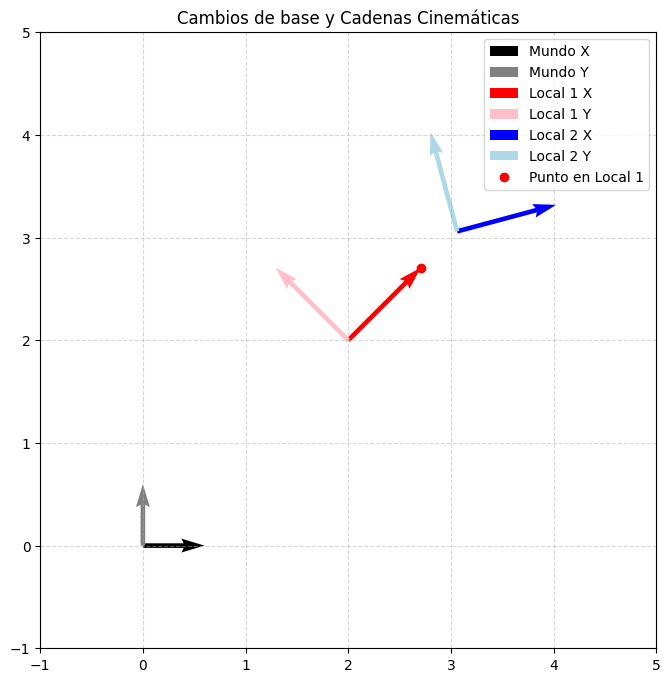

In [6]:
# Base Global (Mundo)
origin_world = np.array([0, 0])
x_axis_world = np.array([1, 0])
y_axis_world = np.array([0, 1])

# Sistema local 1 (Origen en (2, 2), Rotado 45°)
T_local1 = translation_2d(2, 2)
R_local1 = rotation_2d(45)
M_world_to_local1 = T_local1 @ R_local1

# Punto P en coordenadas de local 1 -> (1, 0)
p_local1 = np.array([[1, 0]])
p_world = apply_transformation(p_local1, M_world_to_local1)

# Sistema local 2 (Respecto a local 1: Traslación de (1.5, 0) en su X local y rotación de -30°)
T_local2 = translation_2d(1.5, 0)
R_local2 = rotation_2d(-30)
M_local1_to_local2 = T_local2 @ R_local2

M_world_to_local2 = M_world_to_local1 @ M_local1_to_local2

# Visualización
fig, ax = plt.subplots(figsize=(8, 8))

# Dibujar Marco Mundo
ax.quiver(*origin_world, *x_axis_world, color='black', scale=10, label='Mundo X')
ax.quiver(*origin_world, *y_axis_world, color='gray', scale=10, label='Mundo Y')

# Puntos para los ejes locales
o_local = np.array([[0,0]])
x_local = np.array([[1,0]])
y_local = np.array([[0,1]])

def plot_frame(ax, matrix, color_x, color_y, label):
    origin = apply_transformation(o_local, matrix)[0]
    x_pt = apply_transformation(x_local, matrix)[0]
    y_pt = apply_transformation(y_local, matrix)[0]
    
    vec_x = x_pt - origin
    vec_y = y_pt - origin
    
    ax.quiver(origin[0], origin[1], vec_x[0], vec_x[1], angles='xy', scale_units='xy', scale=1, color=color_x, label=f'{label} X')
    ax.quiver(origin[0], origin[1], vec_y[0], vec_y[1], angles='xy', scale_units='xy', scale=1, color=color_y, label=f'{label} Y')

plot_frame(ax, M_world_to_local1, 'red', 'pink', 'Local 1')
plot_frame(ax, M_world_to_local2, 'blue', 'lightblue', 'Local 2')

# Punto P en local 1
ax.plot(p_world[0,0], p_world[0,1], 'ro', label='Punto en Local 1')

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.legend()
plt.title("Cambios de base y Cadenas Cinemáticas")
plt.show()


## 5. Transformaciones inversas
- Calcular inversa de matriz de transformación
- Verificar: T * T^(-1) = I
- Aplicar transformación y luego su inversa
- Uso en "deshacer" transformaciones

T * T^-1:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


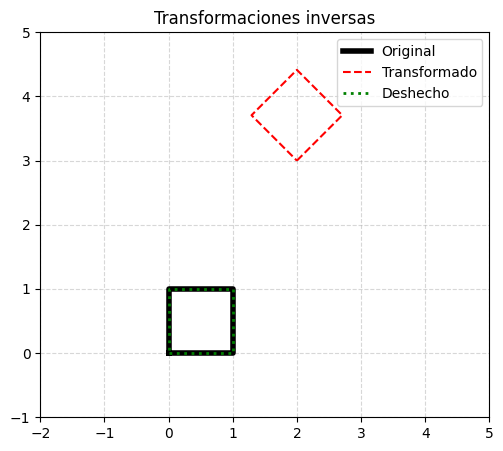

In [7]:
# Matriz M = Traslación(2,3) * Rotación(45)
M_matrix = translation_2d(2,3) @ rotation_2d(45)

# Calcular inversa usando numpy
M_inv = np.linalg.inv(M_matrix)

# Verificar T * T^-1 = I
identity_check = M_matrix @ M_inv
print("T * T^-1:\n", np.round(identity_check, decimals=10))

# Puntos originales
original_points = square.copy()

# 1. Transformar
transformed = apply_transformation(original_points, M_matrix)

# 2. Deshacer transformacion
undone = apply_transformation(transformed, M_inv)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(original_points[:,0], original_points[:,1], label='Original', color='black', linewidth=4)
ax.plot(transformed[:,0], transformed[:,1], label='Transformado', color='red', linestyle='--')
ax.plot(undone[:,0], undone[:,1], label='Deshecho', color='green', linestyle=':', linewidth=2)

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(-2, 5)
ax.set_ylim(-1, 5)
ax.legend()
plt.title("Transformaciones inversas")
plt.show()


## 6. Aplicación en robótica - Brazo Robot
- Modelar brazo robótico con múltiples articulaciones
- Cada articulación tiene su sistema de referencia
- Calcular forward kinematics con transformaciones
- Transformar de espacio de articulación a espacio del mundo
- Visualizar cadena cinemática

# Dependencias

In [8]:
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import plotly.io as pio

pio.renderers.default = "notebook"

# Coordenadas iniciales y matrices de transformación

In [9]:
# Coordinates relative to its father (local)
shoulder = np.array([[0,0,0,1]]).T
elbow = np.array([[4,0,0,1]]).T
wrist = np.array([[2,0,0,1]]).T
hand = np.array([[1,0,0,1]]).T

M_elbow = np.eye(4)
M_elbow[:,3] = elbow[:,0]

Ml_wrist = np.eye(4)
Ml_wrist[:,3] = wrist[:,0]
Mg_wrist = M_elbow @ Ml_wrist

Ml_hand = np.eye(4)
Ml_hand[:,3] = hand[:,0]
Mg_hand = Mg_wrist @ Ml_hand


M_elbow_base = M_elbow.copy()
Ml_wrist_base = Ml_wrist.copy()
Mg_wrist_base = Mg_wrist.copy()
Ml_hand_base = Ml_hand.copy()
Mg_hand_base = Mg_hand.copy()

elbow_t_x = 0
elbow_t_y = 90
elbow_t_z = 90

wrist_t_x = 0
wrist_t_y = 90
wrist_t_z = 90

hand_t_x = 0
hand_t_y = 90
hand_t_z = 90

# Funciones de transofrmación

In [10]:
def rotationMatrix(theta, axis):
    if axis == 'z':
      return np.array([
          [np.cos(theta), -1*np.sin(theta), 0, 0],
          [np.sin(theta), np.cos(theta), 0, 0],
          [0,0,1,0],
          [0,0,0,1]
      ])
    elif axis == 'x':
        return np.array([
            [1, 0, 0, 0],
            [0, np.cos(theta), -1*np.sin(theta), 0],
            [0, np.sin(theta), np.cos(theta), 0],
            [0,0,0,1]

        ])
    elif axis == 'y':
        return np.array([
            [np.cos(theta), 0, np.sin(theta), 0],
            [0,1,0,0],
            [-np.sin(theta),0,np.cos(theta),0],
            [0,0,0,1]
        ])
    else:
      raise Exception("Invalid axis")

def rotateShoulder(theta, axis):
    global M_elbow, Ml_wrist, Mg_wrist, Ml_hand, Mg_hand, elbow_t_x, elbow_t_y, elbow_t_z

    if axis == 'z':
      matrix = rotationMatrix(elbow_t_x, 'x') @ rotationMatrix(elbow_t_y, 'y') @ rotationMatrix(theta, 'z')
      elbow_t_z = theta
    elif axis == 'x':
      matrix = rotationMatrix(theta, 'x') @ rotationMatrix(elbow_t_y, 'y') @ rotationMatrix(elbow_t_z, 'z')
      elbow_t_x = theta
    elif axis == 'y':
      matrix = rotationMatrix(elbow_t_x, 'x') @ rotationMatrix(theta, 'y') @ rotationMatrix(elbow_t_z, 'z')
      elbow_t_y = theta
    else:
      raise Exception("Invalid axis")

    # Perform rotation
    M_elbow = matrix @ M_elbow_base

    # Update children
    Mg_wrist = M_elbow @ Ml_wrist
    Mg_hand = Mg_wrist @ Ml_hand

def rotateElbow(theta, axis):
    global M_elbow, Ml_wrist, Mg_wrist, Ml_hand, Mg_hand, wrist_t_x, wrist_t_y, wrist_t_z

    if axis == 'z':
      matrix = rotationMatrix(wrist_t_x, 'x') @ rotationMatrix(wrist_t_y, 'y') @ rotationMatrix(theta, 'z')
      wrist_t_z = theta
    elif axis == 'x':
      matrix = rotationMatrix(theta, 'x') @ rotationMatrix(wrist_t_y, 'y') @ rotationMatrix(wrist_t_z, 'z')
      wrist_t_x = theta
    elif axis == 'y':
      matrix = rotationMatrix(wrist_t_x, 'x') @ rotationMatrix(theta, 'y') @ rotationMatrix(wrist_t_z, 'z')
      wrist_t_y = theta
    else:
      raise Exception("Invalid axis")

    # Perform rotation
    Ml_wrist = matrix @ Ml_wrist_base
    Mg_wrist = M_elbow @ Ml_wrist
    # Update children
    Mg_hand = Mg_wrist @ Ml_hand


def rotateWrist(theta, axis):
    global M_elbow, Ml_wrist, Mg_wrist, Ml_hand, Mg_hand, hand_t_x, hand_t_y, hand_t_z

    if axis == 'z':
      matrix = rotationMatrix(hand_t_x, 'x') @ rotationMatrix(hand_t_y, 'y') @ rotationMatrix(theta, 'z')
      hand_t_z = theta
    elif axis == 'x':
      matrix = rotationMatrix(theta, 'x') @ rotationMatrix(hand_t_y, 'y') @ rotationMatrix(hand_t_z, 'z')
      hand_t_x = theta
    elif axis == 'y':
      matrix = rotationMatrix(hand_t_x, 'x') @ rotationMatrix(theta, 'y') @ rotationMatrix(hand_t_z, 'z')
      hand_t_y = theta
    else:
      raise Exception("Invalid axis")

    # Perform rotation
    Ml_hand = matrix @ Ml_hand_base
    Mg_hand = Mg_wrist @ Ml_hand



# Gráfico interactivo

In [11]:
# @title
points = np.zeros((4,4));
points[:,0] = np.array([0,0,0,1])
points[:,1] = M_elbow @ np.array([0,0,0,1])
points[:,2] = Mg_wrist @ np.array([0,0,0,1])
points[:,3] = Mg_hand @ np.array([0,0,0,1])

axis_length = 10

x_axis = go.Scatter3d(
    x=[-axis_length, axis_length],
    y=[0, 0],
    z=[0, 0],
    mode='lines',
    line=dict(width=6),
    showlegend=False
)

y_axis = go.Scatter3d(
    x=[0, 0],
    y=[-axis_length, axis_length],
    z=[0, 0],
    mode='lines',
    line=dict(width=6),
    showlegend=False
)

z_axis = go.Scatter3d(
    x=[0, 0],
    y=[0, 0],
    z=[-axis_length, axis_length],
    mode='lines',
    line=dict(width=6),
    showlegend=False
)

fig = go.FigureWidget(
    data=[
        go.Scatter3d(
            x=points[0, :],
            y=points[1, :],
            z=points[2, :],
            mode='markers+lines',
            marker=dict(size=6),
            line=dict(width=6)
        ),
        x_axis,
        y_axis,
        z_axis
    ],
    layout=go.Layout(
        scene=dict(
            xaxis=dict(
                range=[-10, 10],
                autorange=False,
                showgrid=True,
                zeroline=False
            ),
            yaxis=dict(
                range=[-10, 10],
                autorange=False,
                showgrid=True,
                zeroline=False
            ),
            zaxis=dict(
                range=[-10, 10],
                autorange=False,
                showgrid=True,
                zeroline=False
            ),
            aspectmode='cube',
            bgcolor='white'
        ),
        margin=dict(l=0, r=0, b=0, t=0),
        height=500,
        width=500
    )
)

fig.layout.scene.xaxis.autorange = False
fig.layout.scene.yaxis.autorange = False
fig.layout.scene.zaxis.autorange = False

fig.layout.scene.xaxis.range = [-10, 10]
fig.layout.scene.yaxis.range = [-10, 10]
fig.layout.scene.zaxis.range = [-10, 10]


display(fig)

def update_points():
    points = np.zeros((4,4));
    points[:,0] = np.array([0,0,0,1])
    points[:,1] = M_elbow @ np.array([0,0,0,1])
    points[:,2] = Mg_wrist @ np.array([0,0,0,1])
    points[:,3] = Mg_hand @ np.array([0,0,0,1])

    with fig.batch_update():
        fig.data[0].x = points[0, :]
        fig.data[0].y = points[1, :]
        fig.data[0].z = points[2, :]

def update_shoulder(val, axis):
    theta = np.deg2rad(val)
    rotateShoulder(theta, axis)
    update_points()

def update_elbow(val, axis):
    theta = np.deg2rad(val)
    rotateElbow(theta, axis)
    update_points()

def update_wrist(val, axis):
    theta = np.deg2rad(val)
    rotateWrist(theta, axis)
    update_points()


# --- Shoulder ---
interact_sh_x = widgets.interact(
    lambda v: update_shoulder(v, 'x'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=0, description='Shoulder X')
)

interact_sh_y = widgets.interact(
    lambda v: update_shoulder(v, 'y'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=90, description='Shoulder Y')
)

interact_sh_z = widgets.interact(
    lambda v: update_shoulder(v, 'z'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=90, description='Shoulder Z')
)

# --- elbow ---
interact_el_x = widgets.interact(
    lambda v: update_elbow(v, 'x'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=0, description='Elbow X')
)

interact_el_y = widgets.interact(
    lambda v: update_elbow(v, 'y'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=90, description='Elbow Y')
)

interact_el_z = widgets.interact(
    lambda v: update_elbow(v, 'z'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=90, description='Elbow Z')
)

# --- Wrist ---
interact_wr_x = widgets.interact(
    lambda v: update_wrist(v, 'x'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=0, description='Wrist X')
)

interact_wr_y = widgets.interact(
    lambda v: update_wrist(v, 'y'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=90, description='Wrist Y')
)

interact_wr_z = widgets.interact(
    lambda v: update_wrist(v, 'z'),
    v=widgets.FloatSlider(min=-180, max=180, step=1, value=90, description='Wrist Z')
)


FigureWidget({
    'data': [{'line': {'width': 6},
              'marker': {'size': 6},
              'mode': 'markers+lines',
              'type': 'scatter3d',
              'uid': 'bc704ef9-92cd-48df-882f-dc71c771ad97',
              'x': {'bdata': 'AAAAAAAAAAAAAAAAAAAQQAAAAAAAABhAAAAAAAAAHEA=', 'dtype': 'f8'},
              'y': {'bdata': 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA=', 'dtype': 'f8'},
              'z': {'bdata': 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA=', 'dtype': 'f8'}},
             {'line': {'width': 6},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter3d',
              'uid': '50a19e35-8afc-40a2-bd90-09a7f4f1fff4',
              'x': [-10, 10],
              'y': [0, 0],
              'z': [0, 0]},
             {'line': {'width': 6},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter3d',
              'uid': '228bac89-ebe7-46d8-a8b0-ef542ba9a264',
              'x

interactive(children=(FloatSlider(value=0.0, description='Shoulder X', max=180.0, min=-180.0, step=1.0), Outpu…

interactive(children=(FloatSlider(value=90.0, description='Shoulder Y', max=180.0, min=-180.0, step=1.0), Outp…

interactive(children=(FloatSlider(value=90.0, description='Shoulder Z', max=180.0, min=-180.0, step=1.0), Outp…

interactive(children=(FloatSlider(value=0.0, description='Elbow X', max=180.0, min=-180.0, step=1.0), Output()…

interactive(children=(FloatSlider(value=90.0, description='Elbow Y', max=180.0, min=-180.0, step=1.0), Output(…

interactive(children=(FloatSlider(value=90.0, description='Elbow Z', max=180.0, min=-180.0, step=1.0), Output(…

interactive(children=(FloatSlider(value=0.0, description='Wrist X', max=180.0, min=-180.0, step=1.0), Output()…

interactive(children=(FloatSlider(value=90.0, description='Wrist Y', max=180.0, min=-180.0, step=1.0), Output(…

interactive(children=(FloatSlider(value=90.0, description='Wrist Z', max=180.0, min=-180.0, step=1.0), Output(…